In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
import numpy as np
import missingno as msno
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek

In [2]:
df = pd.read_csv('/content/medical-appointments-no-show-en (1).csv')
print(df.isna().sum())
df = df.drop(columns=['icd', 'no_show_reason'])

specialty                   7454
appointment_time               0
gender                         0
appointment_date               0
no_show                        0
no_show_reason             47856
disability                  5137
date_of_birth              10321
entry_service_date          5155
city                        5181
icd                        38876
appointment_month              0
appointment_year               0
appointment_shift              0
age                        10350
under_12_years_old             0
over_60_years_old              0
patient_needs_companion        0
average_temp_day            1016
average_rain_day            1016
max_temp_day                1016
max_rain_day                1016
rainy_day_before               0
storm_day_before               0
rain_intensity                 0
heat_intensity                 0
dtype: int64


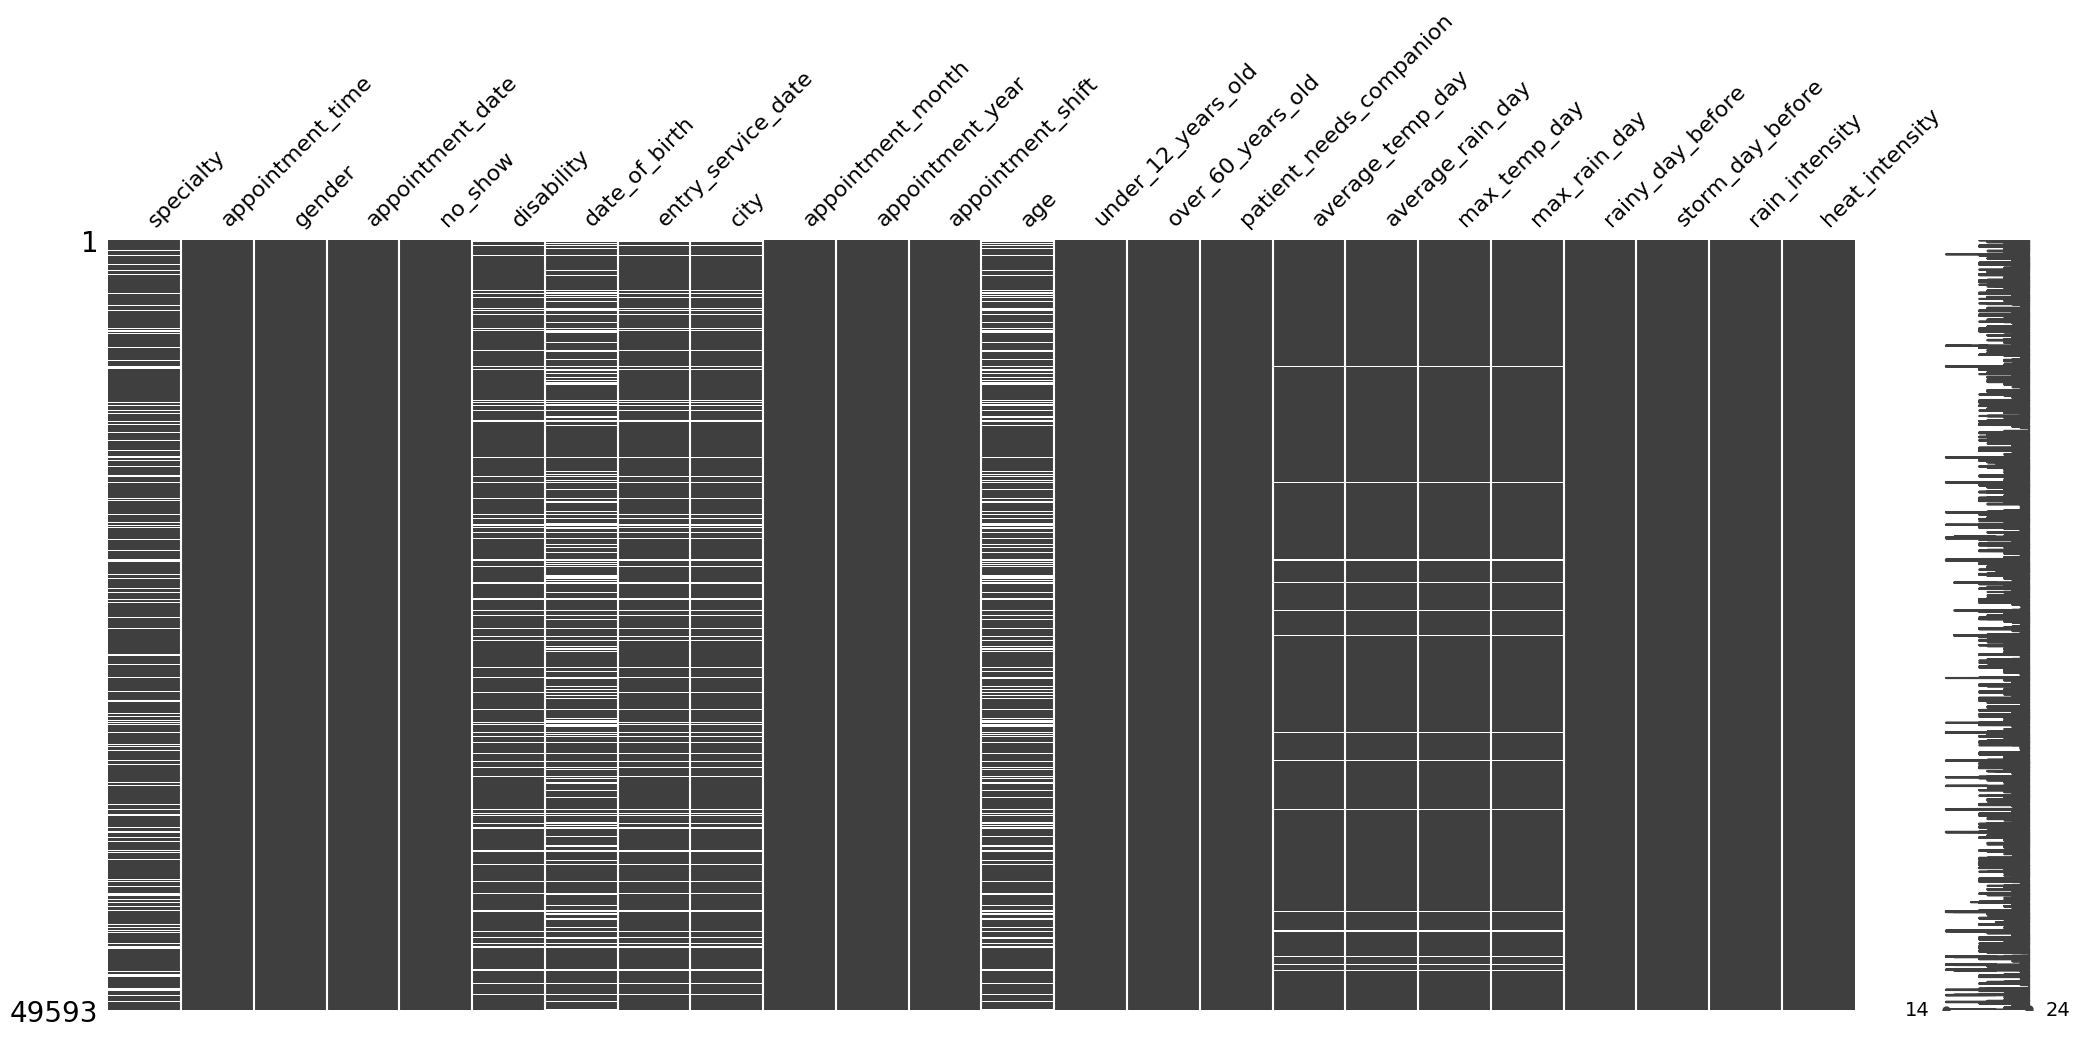

In [3]:
msno.matrix(df)
plt.show()

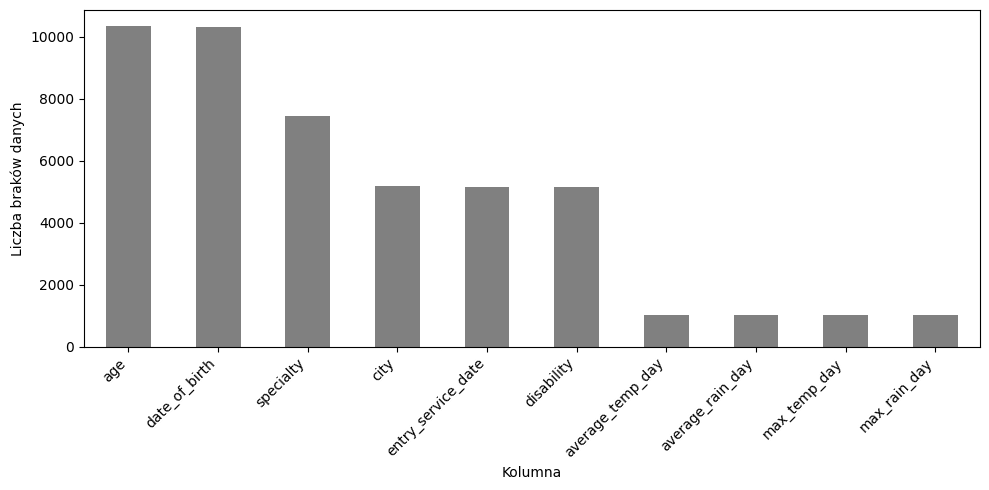

In [4]:
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
plt.figure(figsize=(10, 5))
missing_counts.sort_values(ascending=False).plot(kind='bar', color='grey')
plt.ylabel('Liczba braków danych')
plt.xlabel('Kolumna')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
df = df.dropna(subset=['average_temp_day'])
df = df.drop(columns=['rainy_day_before', 'storm_day_before'])
print(df.isna().sum())

specialty                  6935
appointment_time              0
gender                        0
appointment_date              0
no_show                       0
disability                 4442
date_of_birth              9620
entry_service_date         4460
city                       4486
appointment_month             0
appointment_year              0
appointment_shift             0
age                        9649
under_12_years_old            0
over_60_years_old             0
patient_needs_companion       0
average_temp_day              0
average_rain_day              0
max_temp_day                  0
max_rain_day                  0
rain_intensity                0
heat_intensity                0
dtype: int64


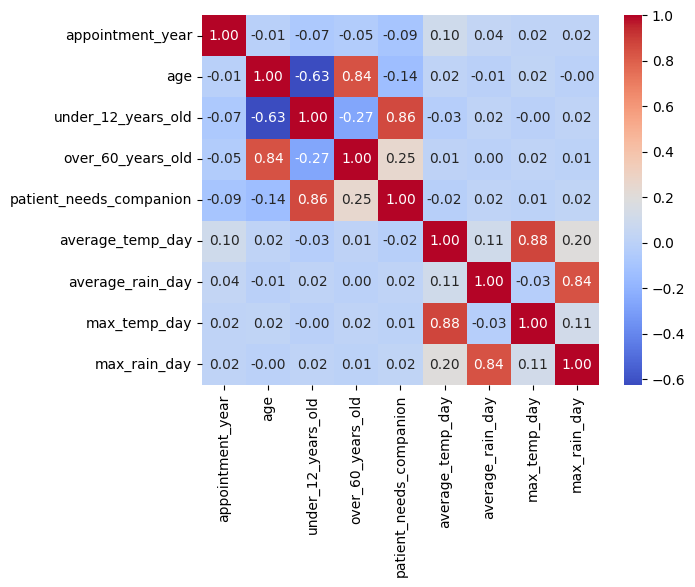

In [6]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])
corr = df_numeric.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [7]:
nan_age_rows = df[df['age'].isna()]
print(nan_age_rows[['age', 'over_60_years_old', 'under_12_years_old']])

for col in ['over_60_years_old', 'under_12_years_old']:
    unique_vals = nan_age_rows[col].unique()
    print(f"{col} unique values for rows with NaN age: {unique_vals}")

       age  over_60_years_old  under_12_years_old
0      NaN                  0                   0
1      NaN                  0                   0
2      NaN                  0                   0
3      NaN                  0                   0
7      NaN                  0                   0
...    ...                ...                 ...
49548  NaN                  0                   0
49553  NaN                  0                   0
49555  NaN                  0                   0
49559  NaN                  0                   0
49560  NaN                  0                   0

[9649 rows x 3 columns]
over_60_years_old unique values for rows with NaN age: [0]
under_12_years_old unique values for rows with NaN age: [0]


In [9]:
age_missing_dob_present = ((df['age'].isna()) & (df['date_of_birth'].notna())).sum()

invalid_dates = df.loc[
    (df['date_of_birth'].notna()) &
    (pd.to_datetime(df['date_of_birth'], dayfirst=True, errors='coerce').isna())
]
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], dayfirst=True, errors='coerce')
df = df.drop(columns=['date_of_birth'])

In [10]:
df = df.drop(columns=['average_temp_day', 'average_rain_day'])

In [11]:
df['appointment_date'] = pd.to_datetime(df['appointment_date'], errors='coerce', dayfirst=True)
df['appointment_day'] = df['appointment_date'].dt.day
df = df.drop(columns=['appointment_date'])

df['entry_service_date'] = pd.to_datetime(df['entry_service_date'], errors='coerce', dayfirst=True)
df['entry_day'] = df['entry_service_date'].dt.day
df['entry_month'] = df['entry_service_date'].dt.month
df['entry_year'] = df['entry_service_date'].dt.year
df = df.drop(columns=['entry_service_date'])

df['appointment_time'] = pd.to_datetime(df['appointment_time'], format='%H:%M', errors='coerce')
df['appointment_hour'] = df['appointment_time'].dt.hour
df['appointment_minute'] = df['appointment_time'].dt.minute
df = df.drop(columns=['appointment_time'])

In [12]:
# Cyclical encoding
df['appointment_minute_sin'] = np.sin(2 * np.pi * df['appointment_minute'] / 60)
df['appointment_minute_cos'] = np.cos(2 * np.pi * df['appointment_minute'] / 60)

df['appointment_hour_sin'] = np.sin(2 * np.pi * df['appointment_hour'] / 24)
df['appointment_hour_cos'] = np.cos(2 * np.pi * df['appointment_hour'] / 24)

df['appointment_day_sin'] = np.sin(2 * np.pi * df['appointment_day'] / 31)
df['appointment_day_cos'] = np.cos(2 * np.pi * df['appointment_day'] / 31)

df = df.drop(columns=['appointment_minute','appointment_hour', 'appointment_day'])

In [13]:
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'april': 4, 'may': 5, 'june': 6,
    'july': 7, 'aug': 8, 'sept': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
df['appointment_month'] = df['appointment_month'].map(month_map)

df['appointment_month_sin'] = np.sin(2 * np.pi * df['appointment_month'] / 12)
df['appointment_month_cos'] = np.cos(2 * np.pi * df['appointment_month'] / 12)
df = df.drop(columns=['appointment_month'])

df['no_show'] = df['no_show'].map({'no': 0, 'yes': 1})
df['appointment_shift'] = df['appointment_shift'].map({'morning': 0, 'afternoon': 1})
df['appointment_year'] = df['appointment_year'] - df['appointment_year'].min()
df['entry_year'] = df['entry_year'] - df['entry_year'].min()

In [14]:
print(df.isna().sum())

specialty                  6935
gender                        0
no_show                       0
disability                 4442
city                       4486
appointment_year              0
appointment_shift             0
age                        9649
under_12_years_old            0
over_60_years_old             0
patient_needs_companion       0
max_temp_day                  0
max_rain_day                  0
rain_intensity                0
heat_intensity                0
entry_day                  4854
entry_month                4854
entry_year                 4854
appointment_minute_sin        0
appointment_minute_cos        0
appointment_hour_sin          0
appointment_hour_cos          0
appointment_day_sin           0
appointment_day_cos           0
appointment_month_sin         0
appointment_month_cos         0
dtype: int64


In [15]:
categorical_cols = ['gender', 'heat_intensity', 'rain_intensity', 'specialty', 'disability', 'city']
df[categorical_cols] = df[categorical_cols].fillna('Unknown')
df = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols, dtype=int)

In [16]:
print(df.isna().sum())

no_show                              0
appointment_year                     0
appointment_shift                    0
age                               9649
under_12_years_old                   0
over_60_years_old                    0
patient_needs_companion              0
max_temp_day                         0
max_rain_day                         0
entry_day                         4854
entry_month                       4854
entry_year                        4854
appointment_minute_sin               0
appointment_minute_cos               0
appointment_hour_sin                 0
appointment_hour_cos                 0
appointment_day_sin                  0
appointment_day_cos                  0
appointment_month_sin                0
appointment_month_cos                0
gender_F                             0
gender_I                             0
gender_M                             0
heat_intensity_cold                  0
heat_intensity_heavy_cold            0
heat_intensity_heavy_warm

In [17]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

modes = {}
for col in ['entry_day', 'entry_month', 'entry_year']:
    modes[col] = train_df[col].mode()[0]
for col in modes:
    train_df[col] = train_df[col].fillna(modes[col])
for col in modes:
    test_df[col] = test_df[col].fillna(modes[col])
for col in ['entry_day', 'entry_month', 'entry_year']:
    train_df[col] = train_df[col].astype(int)
    test_df[col] = test_df[col].astype(int)


train_df['entry_day_sin'] = np.sin(2 * np.pi * train_df['entry_day'] / 31)
train_df['entry_day_cos'] = np.cos(2 * np.pi * train_df['entry_day'] / 31)
test_df['entry_day_sin'] = np.sin(2 * np.pi * test_df['entry_day'] / 31)
test_df['entry_day_cos'] = np.cos(2 * np.pi * test_df['entry_day'] / 31)
train_df['entry_month_sin'] = np.sin(2 * np.pi * train_df['entry_month'] / 12)
train_df['entry_month_cos'] = np.cos(2 * np.pi * train_df['entry_month'] / 12)
test_df['entry_month_sin'] = np.sin(2 * np.pi * test_df['entry_month'] / 12)
test_df['entry_month_cos'] = np.cos(2 * np.pi * test_df['entry_month'] / 12)

train_df = train_df.drop(columns=['entry_day', 'entry_month'])
test_df = test_df.drop(columns=['entry_day', 'entry_month'])

In [18]:
mean_age = train_df[(train_df['over_60_years_old'] == 0) & (train_df['under_12_years_old'] == 0)]['age'].mean()
print(f"Conditional mean age: {mean_age}")
train_df['age'] = train_df['age'].fillna(mean_age)
test_df['age'] = test_df['age'].fillna(mean_age)

Conditional mean age: 22.767482161060144


In [19]:
train_df = train_df.drop(columns=['under_12_years_old', 'over_60_years_old'])
test_df = test_df.drop(columns=['under_12_years_old', 'over_60_years_old'])

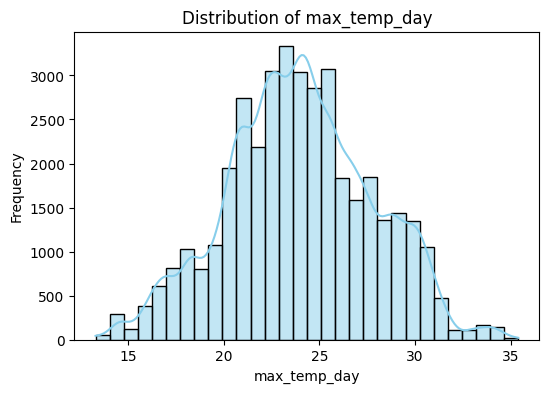

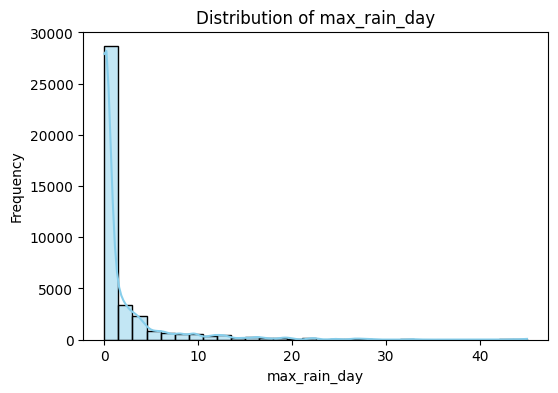

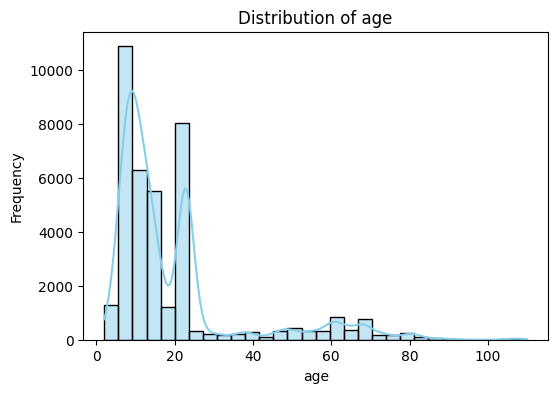

In [20]:
numeric_cols = ['max_temp_day', 'max_rain_day', 'age']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(train_df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [22]:
train_df['age'] = np.log1p(train_df['age'])
test_df['age'] = np.log1p(test_df['age'])
train_df['max_rain_day'] = np.log1p(train_df['max_rain_day'])
test_df['max_rain_day'] = np.log1p(test_df['max_rain_day'])

In [23]:
std_scaler = StandardScaler()
robust_scaler = RobustScaler()

train_df['max_temp_day'] = std_scaler.fit_transform(train_df[['max_temp_day']])
test_df['max_temp_day'] = std_scaler.transform(test_df[['max_temp_day']])

train_df['age'] = std_scaler.fit_transform(train_df[['age']])
test_df['age'] = std_scaler.transform(test_df[['age']])

train_df['max_rain_day'] = robust_scaler.fit_transform(train_df[['max_rain_day']])
test_df['max_rain_day'] = robust_scaler.transform(test_df[['max_rain_day']])

In [24]:
for col in train_df.columns:
    print(f"{col}: {train_df[col].nunique()} unique values")
    print(train_df[col].unique()[:10])
    print("------")

no_show: 2 unique values
[0 1]
------
appointment_year: 6 unique values
[2 5 1 3 0 4]
------
appointment_shift: 2 unique values
[0 1]
------
age: 88 unique values
[-1.05957429 -0.57173157  1.7477771  -0.4384379   0.60848789 -0.31581961
 -0.2022928  -0.71773827  0.00226538 -0.09660188]
------
patient_needs_companion: 2 unique values
[1 0]
------
max_temp_day: 185 unique values
[ 1.29085727  0.03267594  0.34722127  0.21616071 -1.04202062  0.71419083
 -1.17308118 -0.96338429 -0.30808151 -0.57020262]
------
max_rain_day: 84 unique values
[ 0.80918956 -0.19081044  0.          0.30107653  1.90385835  0.53460963
  1.84570117  1.0264966   2.01129208  0.63435745]
------
entry_year: 7 unique values
[3 6 2 4 5 1 0]
------
appointment_minute_sin: 12 unique values
[ 5.66553890e-16 -8.66025404e-01  8.66025404e-01  0.00000000e+00
  5.00000000e-01  8.66025404e-01 -5.00000000e-01 -8.66025404e-01
  1.00000000e+00 -1.00000000e+00]
------
appointment_minute_cos: 12 unique values
[-1.00000000e+00 -5.000000

In [25]:
X_train = train_df.drop('no_show', axis=1)
y_train = train_df['no_show']

X_test = test_df.drop('no_show', axis=1)
y_test = test_df['no_show']

y_train_original = y_train.copy()
smote = SMOTETomek(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [26]:
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)

X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

X_train_res.to_csv('X_train_res.csv', index=False)
y_train_res.to_csv('y_train_res.csv', index=False)